In [2]:
import sys
!{sys.executable} -m pip install tensorflow


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [3]:
import sys
!{sys.executable} -m pip install tensorflow

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [4]:
import sys
!{sys.executable} -m pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 6.4 MB/s  0:00:13m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 7.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 7.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torchvision] [torchvision]


In [5]:
import torch
print(torch.__version__)
print("PyTorch ready!")

2.12.0
PyTorch ready!


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and clean data — same as before
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].dropna()
df['sex']      = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X = df.drop('survived', axis=1).values
y = df['survived'].values

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test  = torch.FloatTensor(y_test)

print("Data ready!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Data ready!
X_train shape: torch.Size([569, 5])
X_test shape:  torch.Size([143, 5])


In [7]:
# Define the neural network
class TitanicNet(nn.Module):
    def __init__(self):
        super(TitanicNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 64),   # input layer: 5 features → 64 neurons
            nn.ReLU(),           # activation function
            nn.Linear(64, 32),  # hidden layer: 64 → 32 neurons
            nn.ReLU(),           # activation function
            nn.Linear(32, 1),   # output layer: 32 → 1 neuron
            nn.Sigmoid()         # squish to 0-1 probability
        )
    
    def forward(self, x):
        return self.network(x)

# Create model
model = TitanicNet()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

TitanicNet(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 2497


In [8]:
# Loss function and optimizer
criterion = nn.BCELoss()           # Binary Cross Entropy for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
losses = []

for epoch in range(epochs):
    model.train()
    
    # Forward pass
    predictions = model(X_train).squeeze()
    loss = criterion(predictions, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/100 | Loss: {loss.item():.4f}")

Epoch  10/100 | Loss: 0.6554
Epoch  20/100 | Loss: 0.6103
Epoch  30/100 | Loss: 0.5583
Epoch  40/100 | Loss: 0.5052
Epoch  50/100 | Loss: 0.4628
Epoch  60/100 | Loss: 0.4393
Epoch  70/100 | Loss: 0.4283
Epoch  80/100 | Loss: 0.4205
Epoch  90/100 | Loss: 0.4145
Epoch 100/100 | Loss: 0.4099


Test Accuracy: 0.8042


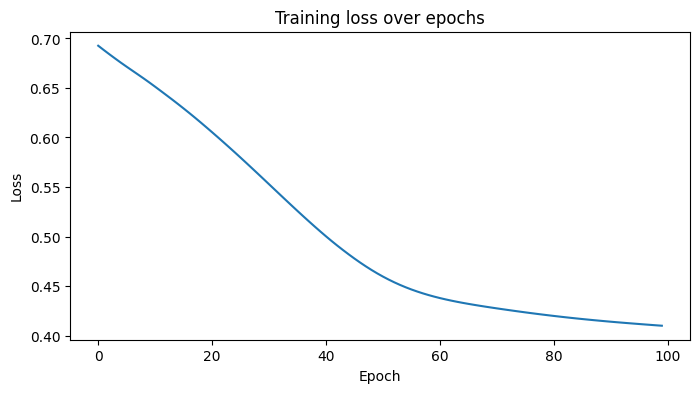

In [9]:
model.eval()
with torch.no_grad():
    test_predictions = model(X_test).squeeze()
    test_predictions_binary = (test_predictions >= 0.5).float()
    accuracy = (test_predictions_binary == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")

# Plot training loss
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('Training loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()